# GRU

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import random 
import tensorflow as tf
from math import sqrt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
# from pmdarima import auto_arima

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from keras.models import Sequential
from keras.layers import GRU, Dropout, SimpleRNN, Dense, LSTM
from keras.callbacks import EarlyStopping
from keras.callbacks import ReduceLROnPlateau 

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

### Import Data

In [2]:
data = pd.read_csv("/Users/alexzheng/Developer/GitHub/EC331-project/data/Bitcoin_data.csv", 
                   index_col=0, 
                   parse_dates=True) # set index to datetime 

In [3]:
# Normalize the data 
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data)

In [4]:
def create_sequences(data, window_size, target_col_idx):
    """
    data: NumPy array with all features (open, high, low, close)
    window_size: Number of past time steps to use
    target_col_idx: Index of the column to predict (close price = -1)
    """
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size), :])  # Take all columns as input
        y.append(data[i + window_size, target_col_idx])  # Only the close price as output
    return np.array(X), np.array(y)

window_size = 15

target_col_idx = data.columns.get_loc("close")
X, y = create_sequences(data_normalized, window_size, target_col_idx=target_col_idx)
X = X.reshape((X.shape[0], X.shape[1], X.shape[2]))  # Keep all features

### Split

In [5]:
split = int(len(X) * 0.8)  # 80% training, 20% testing
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (47062, 15, 4)
y_train shape: (47062,)
X_test shape: (11766, 15, 4)
y_test shape: (11766,)


## GRU

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 30)             │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,271 (12.78 KB)

 Trainable params: 3,271 (12.78 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0142 - val_loss: 3.7638e-04
Epoch 2/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0018 - val_loss: 6.2717e-04
Epoch 3/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0013 - val_loss: 2.5064e-04
Epoch 4/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0011 - val_loss: 5.1898e-04
Epoch 5/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 9.3340e-04 - val_loss: 5.2435e-04
Epoch 6/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.6988e-04 - val_loss: 8.9707e-04
Epoch 7/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.2329e-04 - val_loss: 4.0806e-04
Epoch 8/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.2744e-04 - val_loss: 3.7357e-04
Epoch 9/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.7487e-04 - val_loss: 1.3721e-04
Epoch 10/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.9339e-04 - val_loss: 2.8475e-04
Epoch 11/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.8780e-04 - v

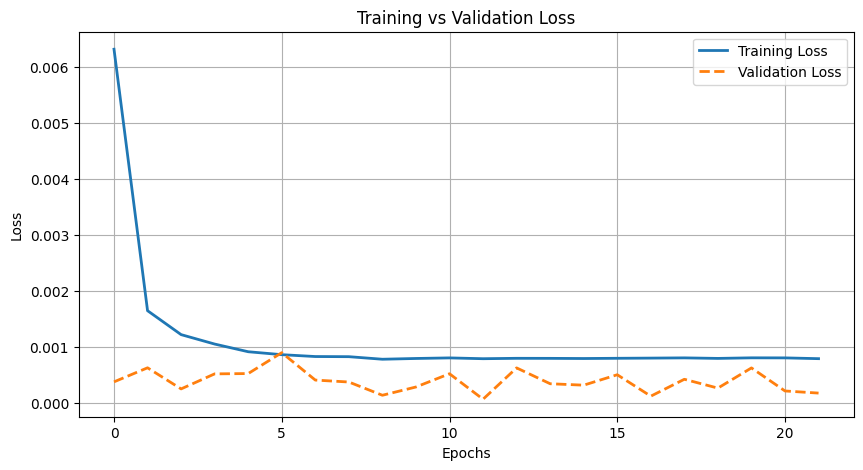

368/368 ━━━━━━━━━━━━━━━━━━━━ 0s 686us/step
Mean Absolute Error (MAE): 549.6062
Root Mean Squared Error (RMSE): 857.0545
Mean Absolute Percentage Error (MAPE): 0.76%


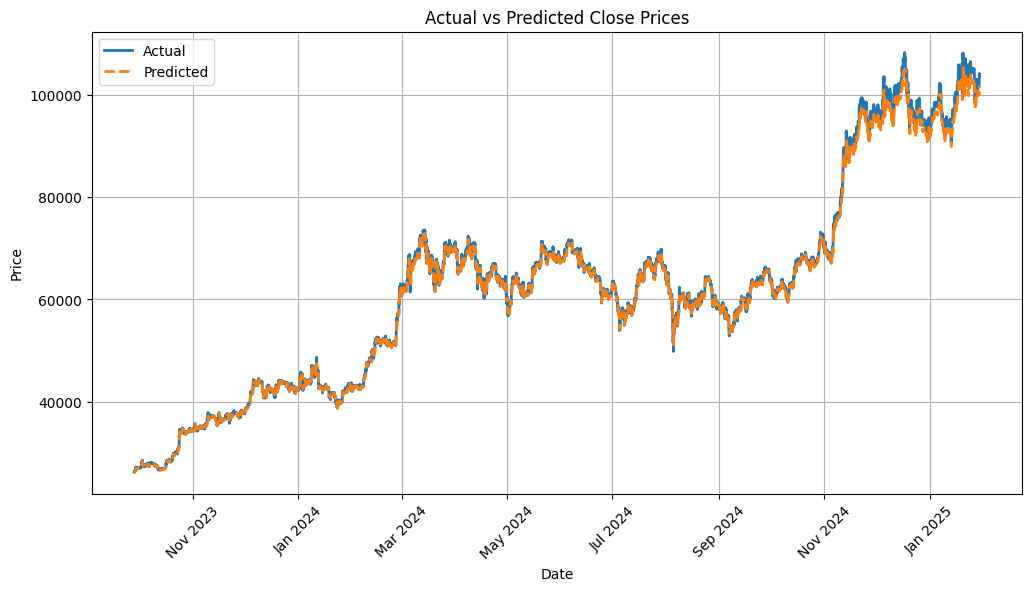

In [6]:
gru_model = Sequential()

# One GRU layer with dropout
gru_model.add(GRU(30, return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])))
gru_model.add(Dropout(0.5))

# Output layer: predicting only the close prices (1 feature)
gru_model.add(Dense(1))

# Compile the model 
optimizer = tf.keras.optimizers.Adam()
gru_model.compile(optimizer=optimizer, loss='mean_squared_error')

# Model Summary
gru_model.summary()

# Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

# Train the GRU model with Early Stopping
history = gru_model.fit(X_train, y_train, 
                        epochs=50,  # Increased epochs
                        batch_size=256, 
                        validation_data=(X_test, y_test), 
                        callbacks=[early_stopping],  
                        verbose=1)

# Plot Training vs Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='dashed')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Use a separate scaler for close prices
close_scaler = MinMaxScaler()
data['close'] = close_scaler.fit_transform(data[['close']])

# Make predictions
predicted_gru = gru_model.predict(X_test)

# Inverse transform predictions
predicted_gru = close_scaler.inverse_transform(predicted_gru.reshape(-1, 1))
y_test_actual = close_scaler.inverse_transform(y_test.reshape(-1, 1))

# Compute error metrics
mae = mean_absolute_error(y_test_actual, predicted_gru)
mse = mean_squared_error(y_test_actual, predicted_gru)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test_actual - predicted_gru) / y_test_actual)) * 100  

# Print results
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

# Ensure the date index is in datetime format
date_index = pd.to_datetime(data.index[-len(y_test_actual):])

# Plot Actual vs Predicted Prices
plt.figure(figsize=(12, 6))
plt.plot(date_index, y_test_actual, label='Actual', linewidth=2)
plt.plot(date_index, predicted_gru, label='Predicted', linewidth=2, linestyle='dashed')

plt.title('Actual vs Predicted Close Prices')
plt.xlabel('Date')
plt.ylabel('Price')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))  
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()